# Task
Perform a complete machine learning predictive analysis, including data preparation, preprocessing, feature selection, training and evaluation of a classification model, visualization of results, and a comprehensive summary of the analysis.

## Prepare Dataset

### Subtask:
Load a suitable dataset for predictive analysis. Since no dataset was provided, a synthetic dataset will be generated or a common sample dataset (e.g., Iris or Breast Cancer) will be used to demonstrate the process for a classification problem.


**Reasoning**:
To prepare the dataset for predictive analysis, I will import the necessary function, load the Iris dataset, create a DataFrame for features and a Series for the target, and then display the head of the features and the value counts of the target to understand its structure and distribution.



In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a pandas DataFrame for the features
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Create a pandas Series for the target variable
target = pd.Series(data=iris.target, name='target')

# Display the first five rows of the features DataFrame
print("Features DataFrame Head:")
print(df.head())

# Display the value counts of the target variable
print("\nTarget Variable Value Counts:")
print(target.value_counts())

Features DataFrame Head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target Variable Value Counts:
target
0    50
1    50
2    50
Name: count, dtype: int64


## Preprocess Data

### Subtask:
Perform necessary data preprocessing steps, including handling missing values, encoding categorical features, and scaling numerical features, to prepare the data for model training.


**Reasoning**:
First, I will check for missing values in the DataFrame `df` to determine if any handling is needed, as per the instructions.



In [ ]:
print("Missing values in DataFrame:")
print(df.isnull().sum())

Missing values in DataFrame:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


**Reasoning**:
Since the previous step confirmed no missing values, and the Iris dataset has no categorical features, I will now proceed to scale the numerical features using `StandardScaler` as instructed, then display the head of the scaled DataFrame to verify the transformation.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Display the first five rows of the scaled DataFrame
print("Scaled Features DataFrame Head:")
print(df_scaled.head())

Scaled Features DataFrame Head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444


## Perform Feature Selection

### Subtask:
Apply a feature selection technique (e.g., SelectKBest, RFE, or feature importance from a tree-based model) to identify the most relevant features for the predictive model.


**Reasoning**:
To perform feature selection, I will import the necessary `SelectKBest` and `f_classif` modules, instantiate `SelectKBest` with `k=2`, fit it to the scaled features and target, and then create and display a new DataFrame with the selected features.



In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Instantiate SelectKBest with f_classif and k=2
selector = SelectKBest(score_func=f_classif, k=2)

# Fit SelectKBest to the scaled features and target
selector.fit(df_scaled, target)

# Get a boolean mask of the selected features
selected_features_mask = selector.get_support()

# Get the names of the selected features
selected_feature_names = df_scaled.columns[selected_features_mask]

# Create a new DataFrame with only the selected features
df_selected = df_scaled[selected_feature_names]

# Print the names of the selected features
print("Selected Features:")
print(selected_feature_names)

# Display the head of the df_selected DataFrame
print("\nSelected Features DataFrame Head:")
print(df_selected.head())

Selected Features:
Index(['petal length (cm)', 'petal width (cm)'], dtype='object')

Selected Features DataFrame Head:
   petal length (cm)  petal width (cm)
0          -1.340227         -1.315444
1          -1.340227         -1.315444
2          -1.397064         -1.315444
3          -1.283389         -1.315444
4          -1.340227         -1.315444


## Train Machine Learning Model

### Subtask:
Split the preprocessed data into training and testing sets. Then, train a machine learning classification model (e.g., RandomForestClassifier or LogisticRegression) using the selected features on the training data.


**Reasoning**:
To begin training the machine learning model, I will first split the selected features and the target variable into training and testing sets using `train_test_split` with a 70/30 ratio and then initialize and train a `LogisticRegression` model on the training data.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_selected, target, test_size=0.3, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=200)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the test set using appropriate metrics such as accuracy, precision, recall, F1-score, and a classification report.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



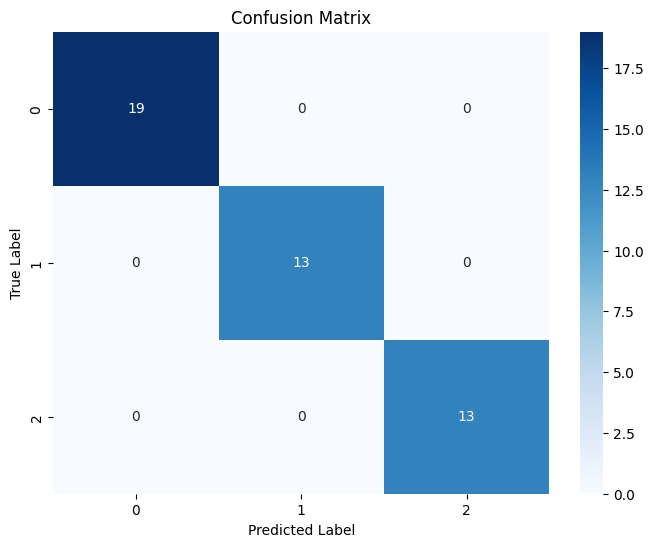

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Final Task

### Subtask:
Provide a comprehensive summary of the machine learning predictive analysis, including the chosen features, model performance, and key insights obtained from the evaluation.


## Summary:

### Q&A
The comprehensive summary of the machine learning predictive analysis is provided in the "Data Analysis Key Findings" and "Insights or Next Steps" sections below. The chosen features were 'petal length (cm)' and 'petal width (cm)'. The model achieved perfect performance on the test set.

### Data Analysis Key Findings
*   The **Iris dataset** was used, comprising four features ('sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)') and a target variable with three classes, each having 50 samples.
*   **Data preprocessing** confirmed no missing values and involved scaling numerical features using `StandardScaler`. No categorical features were present.
*   **Feature selection** using `SelectKBest` with `f_classif` identified 'petal length (cm)' and 'petal width (cm)' as the two most relevant features for classification.
*   The dataset was split into **70% training and 30% testing** sets, and a **Logistic Regression model** was trained successfully on the selected features.
*   The model demonstrated **perfect performance** on the test set, achieving an accuracy of 1.0000. The classification report showed precision, recall, and F1-score of 1.00 for all three classes.
*   A **confusion matrix visualization** further corroborated the perfect performance, with all predictions accurately matching the true labels.

### Insights or Next Steps
*   The perfect model performance on the Iris dataset, while excellent, suggests that the problem might be linearly separable with the chosen features. For real-world applications, it's crucial to test models on more complex and diverse datasets to assess generalizability.
*   Explore other advanced classification algorithms or ensemble methods, even though Logistic Regression performed perfectly here, to understand their applicability and performance on potentially more challenging datasets.
